# Deliverable 1: MJX Setup and Batched Rollouts

This notebook demonstrates the Week 1 requirement:

- install and import MuJoCo, MJX, and JAX
- create CartPole and Walker2d models
- move models/data to MJX
- run single and batched rollouts with `jax.lax.scan` and `jax.vmap`
- extract and plot `qpos` and `qvel` trajectories


In [ ]:
!pip -q install mujoco mujoco-mjx mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.5 MB/s eta 0:00:00


#Task 1.1: Install the required Python dependencies (mujoco, mujoco-mjx, jax)

In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl"

import time
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import lax, random

import mujoco
from mujoco import mjx
import mediapy as media

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


#Task 1.2.1: Spawn both the CartPole and Humanoid models
Using standard MuJoCo, then transfer the models and data to the MJX device (using mjx.put model and mjx.put data)

## CartPole model

In [ ]:
# CartPole model in MuJoCo XML
cartpole_xml = """
<mujoco model="cartpole">
  <compiler coordinate="local" inertiafromgeom="true"/>
  <option timestep="0.01" gravity="0 0 -9.81"/>
  <worldbody>
    <light pos="0 0 3" dir="0 0 -1"/>
    <geom name="floor" type="plane" size="2 2 0.1" rgba="0.8 0.9 0.8 1"/>
    <body name="cart" pos="0 0 0.2">
      <joint name="slider" type="slide" axis="1 0 0" range="-1.5 1.5" limited="true"/>
      <geom name="cart_geom" type="box" size="0.2 0.15 0.1" rgba="0.7 0.2 0.2 1" mass="1.0"/>
      <body name="pole" pos="0 0 0.1">
        <joint name="hinge" type="hinge" axis="0 1 0" range="-90 90"/>
        <geom name="pole_geom" type="capsule" size="0.04 0.4" pos="0 0 0.4" rgba="0.2 0.7 0.2 1" mass="0.1"/>
      </body>
    </body>
  </worldbody>
  <actuator>
    <motor name="slide_motor" joint="slider" ctrlrange="-1 1" ctrllimited="true" gear="10"/>
  </actuator>
</mujoco>
"""

# Builds the CPU MuJoCo model and transfers the model definition to MJX
cart_model = mujoco.MjModel.from_xml_string(cartpole_xml)
cart_cpu_data = mujoco.MjData(cart_model)
cart_mjx_model = mjx.put_model(cart_model)


# Repeatable initial state with a small pole tilt
def make_cartpole_data(theta0=0.05):
    data = mujoco.MjData(cart_model)
    data.qpos[:] = [0.0, theta0]
    data.qvel[:] = [0.0, 0.0]
    mujoco.mj_forward(cart_model, data)
    return mjx.put_data(cart_model, data)


cart_start = make_cartpole_data()
print(f"CartPole: nq={cart_model.nq}, nv={cart_model.nv}, nu={cart_model.nu}")

CartPole: nq=2, nv=2, nu=1


#Task 1.3.1: Implement a batched rollout function
Using jax.vmap and mjx.step to run
multiple environments in parallel.

In [ ]:
H_CART = 300
CART_BATCH = 4096


# MJX data object into a compact state vector [qpos, qvel]
def cart_state(data):
    return jnp.concatenate([data.qpos, data.qvel])


# Roll out applying mjx.step with lax.scan
def cart_rollout(starting_data, actions):
    def step_fn(data, action):
        data = mjx.step(cart_mjx_model, data.replace(ctrl=action))
        return data, cart_state(data)

    _, states = lax.scan(step_fn, starting_data, actions)
    return states


# JIT-compile the rollout and vectorize it over the batch dimension of controls
cart_batched_rollout = jax.jit(jax.vmap(cart_rollout, in_axes=(None, 0)))

# Generate random controls in the valid motor range [-1, 1]
key = random.PRNGKey(0)
cart_actions = random.uniform(
    key, (CART_BATCH, H_CART, cart_model.nu), minval=-1.0, maxval=1.0
)

# Run the batched rollout and time the actual device computation
start_time = time.time()
cart_states = cart_batched_rollout(cart_start, cart_actions)
cart_states.block_until_ready()
elapsed = time.time() - start_time

# Requirements for Deliverable 1: shape, steps, and speed
print("CartPole batched trajectory shape:", cart_states.shape)
print(f"CartPole physics steps: {CART_BATCH * H_CART:,}")
print(f"Elapsed time: {elapsed:.3f}s")
print(f"Steps per second: {(CART_BATCH * H_CART) / elapsed:,.0f}")

CartPole batched trajectory shape: (4096, 300, 4)
CartPole physics steps: 1,228,800
Elapsed time: 17.308s
Steps per second: 70,996


#Task 1.4.1: Verify that you can successfully step the physics and extract the state
(e.g., qpos, qvel) over multiple timesteps for a batch of random actions.

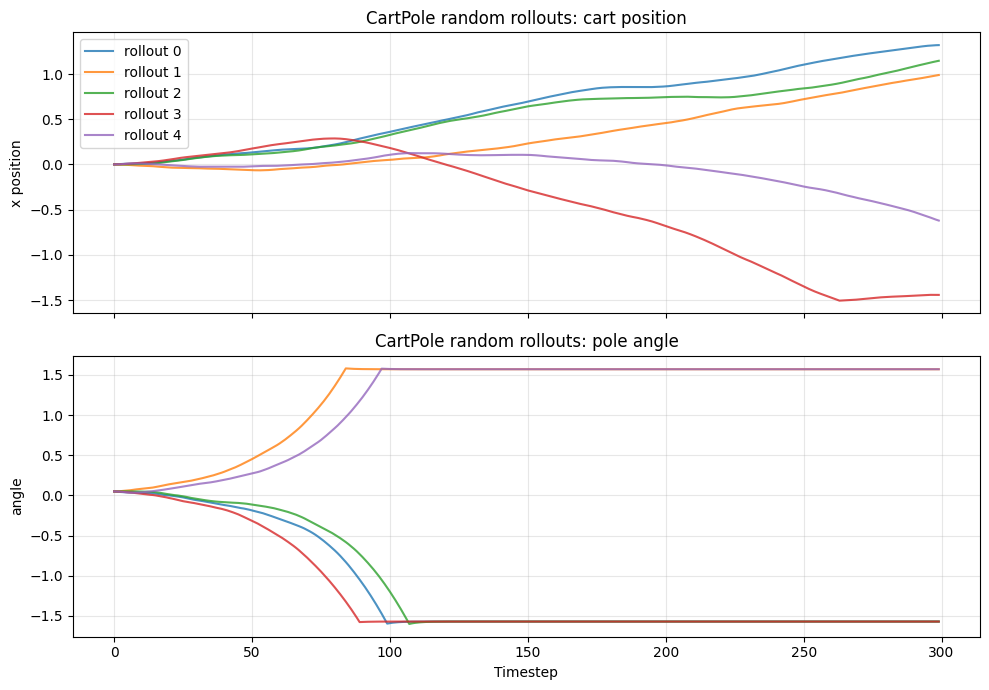

In [ ]:
# Convert the first 5 rollouts to NumPy for plotting
cart_states_np = np.asarray(cart_states[:5])

# Plot a small subset of rollouts (plotting all 4096 would be unreadable)
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for i in range(cart_states_np.shape[0]):
    axes[0].plot(cart_states_np[i, :, 0], alpha=0.8, label=f"rollout {i}")
    axes[1].plot(cart_states_np[i, :, 1], alpha=0.8)

# Cart position over time.
axes[0].set_title("CartPole random rollouts: cart position")
axes[0].set_ylabel("x position")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Pole angle over time.
axes[1].set_title("CartPole random rollouts: pole angle")
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("angle")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Task 1.2.2: Spawn both the CartPole and Humanoid models
Using standard MuJoCo, then transfer the models and data to the MJX device (using mjx.put model and mjx.put data)

## Walker2d locomotion model

In [ ]:
# Walker2d locomotion model from the provided notebook
WALKER2D_XML = r"""
<mujoco model="walker2d">
  <compiler angle="radian" inertiafromgeom="true"/>
  <default>
    <joint limited="true" damping=".05" armature=".1"/>
    <geom contype="0" conaffinity="0" condim="3" density="1000" friction="0.7 0.1 0.1"/>
  </default>
  <option timestep="0.002" integrator="Euler"/>

  <asset>
    <texture type="skybox" builtin="gradient" rgb1=".4 .5 .6" rgb2="0 0 0" width="100" height="100"/>
    <texture builtin="checker" height="100" name="texplane" rgb1="0 0 0" rgb2=".8 .8 .8" type="2d" width="100"/>
    <material name="MatPlane" reflectance="0.5" shininess="1" specular="1" texrepeat="60 60" texture="texplane"/>
  </asset>

  <worldbody>
    <light cutoff="100" diffuse="1 1 1" dir="0 0 -1.3" directional="true" pos="0 0 1.3" specular=".1 .1 .1"/>
    <geom conaffinity="1" condim="3" name="floor" pos="0 0 0" rgba=".8 .9 .8 1" size="40 40 40" type="plane" material="MatPlane"/>

    <body name="torso" pos="0 0 1.25">
      <camera name="track" mode="trackcom" pos="0 -5 0.8" xyaxes="1 0 0 0 0 1" fovy="45"/>
      <joint armature="0" damping="0" limited="false" name="rootx" type="slide" axis="1 0 0"/>
      <joint armature="0" damping="0" limited="false" name="rootz" type="slide" axis="0 0 1" ref="1.25"/>
      <joint armature="0" damping="0" limited="false" name="rooty" type="hinge" axis="0 1 0"/>
      <geom friction="0.9" fromto="0 0 0.07 0 0 0.45" name="torso_geom" size="0.05" type="capsule"/>

      <body name="thigh" pos="0 0 0.07">
        <joint axis="0 -1 0" name="thigh_joint" range="-2.6 0.05" type="hinge"/>
        <geom friction="0.9" fromto="0 0 0 0 0 -0.45" name="thigh_geom" size="0.05" type="capsule"/>
        <body name="leg" pos="0 0 -0.45">
          <joint axis="0 -1 0" name="leg_joint" range="-2.6 -0.1" type="hinge"/>
          <geom friction="0.9" fromto="0 0 0 0 0 -0.5" name="leg_geom" size="0.04" type="capsule"/>
          <body name="foot" pos="0 0 -0.5">
            <joint axis="0 -1 0" name="foot_joint" range="-0.8 0.8" type="hinge"/>
            <geom friction="0.9" fromto="-0.2 0 0 0.2 0 0" name="foot_geom" size="0.06" type="capsule"/>
          </body>
        </body>
      </body>

      <body name="thigh_left" pos="0 0 0.07">
        <joint axis="0 -1 0" name="thigh_left_joint" range="-2.6 0.05" type="hinge"/>
        <geom friction="0.9" fromto="0 0 0 0 0 -0.45" name="thigh_left_geom" size="0.05" type="capsule"/>
        <body name="leg_left" pos="0 0 -0.45">
          <joint axis="0 -1 0" name="leg_left_joint" range="-2.6 -0.1" type="hinge"/>
          <geom friction="0.9" fromto="0 0 0 0 0 -0.5" name="leg_left_geom" size="0.04" type="capsule"/>
          <body name="foot_left" pos="0 0 -0.5">
            <joint axis="0 -1 0" name="foot_left_joint" range="-0.8 0.8" type="hinge"/>
            <geom friction="0.9" fromto="-0.2 0 0 0.2 0 0" name="foot_left_geom" size="0.06" type="capsule"/>
          </body>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="thigh_joint"/>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="leg_joint"/>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="foot_joint"/>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="thigh_left_joint"/>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="leg_left_joint"/>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="foot_left_joint"/>
  </actuator>
</mujoco>
"""

# Builds the CPU MuJoCo model and initializes the derived physics quantities
walker_model = mujoco.MjModel.from_xml_string(WALKER2D_XML)
walker_cpu_data = mujoco.MjData(walker_model)
mujoco.mj_forward(walker_model, walker_cpu_data)

# Transfers the model definition to MJX and creates a data object with the same initial state as the CPU data
walker_mjx_model = mjx.put_model(walker_model)
walker_start = mjx.make_data(walker_mjx_model)

# Defines how many fine physics steps happen for each control action.
N_SUBSTEPS = 5
DT_CTRL = walker_model.opt.timestep * N_SUBSTEPS

print(
    f"Walker2d: nq={walker_model.nq}, nv={walker_model.nv}, "
    f"nu={walker_model.nu}, control_dt={DT_CTRL:.4f}s"
)

Walker2d: nq=9, nv=9, nu=6, control_dt=0.0100s


#Task 1.3.2: Implement a batched rollout function
Using jax.vmap and mjx.step to run
multiple environments in parallel.

In [ ]:
H_WALKER = 64
WALKER_BATCH = 512


# Roll out one Walker action sequence; each control action is held for N_SUBSTEPS
def walker_rollout(starting_data, actions):
    def ctrl_step(data, action):
        data = data.replace(ctrl=action)

        # MJX advances the fine-grained physics several times per controller step
        def physics_step(inner_data, _):
            return mjx.step(walker_mjx_model, inner_data), None

        data, _ = lax.scan(physics_step, data, None, length=N_SUBSTEPS)
        state = jnp.concatenate([data.qpos, data.qvel])
        return data, state

    _, states = lax.scan(ctrl_step, starting_data, actions)
    return states


# Vectorize the single Walker rollout over a batch and compile it.
walker_batched_rollout = jax.jit(jax.vmap(walker_rollout, in_axes=(None, 0)))

# Generate random actuator commands for every rollout and control timestep
key = random.PRNGKey(1)
walker_actions = random.uniform(
    key, (WALKER_BATCH, H_WALKER, walker_model.nu), minval=-1.0, maxval=1.0
)

# Run and time the batched Walker simulation
start_time = time.time()
walker_states = walker_batched_rollout(walker_start, walker_actions)
walker_states.block_until_ready()
elapsed = time.time() - start_time

# Print the rollout shape and speed; main Week 1 evidences
print("Walker2d batched trajectory shape:", walker_states.shape)
print(f"Walker2d control steps: {WALKER_BATCH * H_WALKER:,}")
print(f"Walker2d physics steps: {WALKER_BATCH * H_WALKER * N_SUBSTEPS:,}")
print(f"Elapsed time: {elapsed:.3f}s")
print(f"Physics steps per second: {(WALKER_BATCH * H_WALKER * N_SUBSTEPS) / elapsed:,.0f}")

Walker2d batched trajectory shape: (512, 64, 18)
Walker2d control steps: 32,768
Walker2d physics steps: 163,840
Elapsed time: 22.743s
Physics steps per second: 7,204


#Task 1.4.2: Verify that you can successfully step the physics and extract the state
(e.g., qpos, qvel) over multiple timesteps for a batch of random actions.

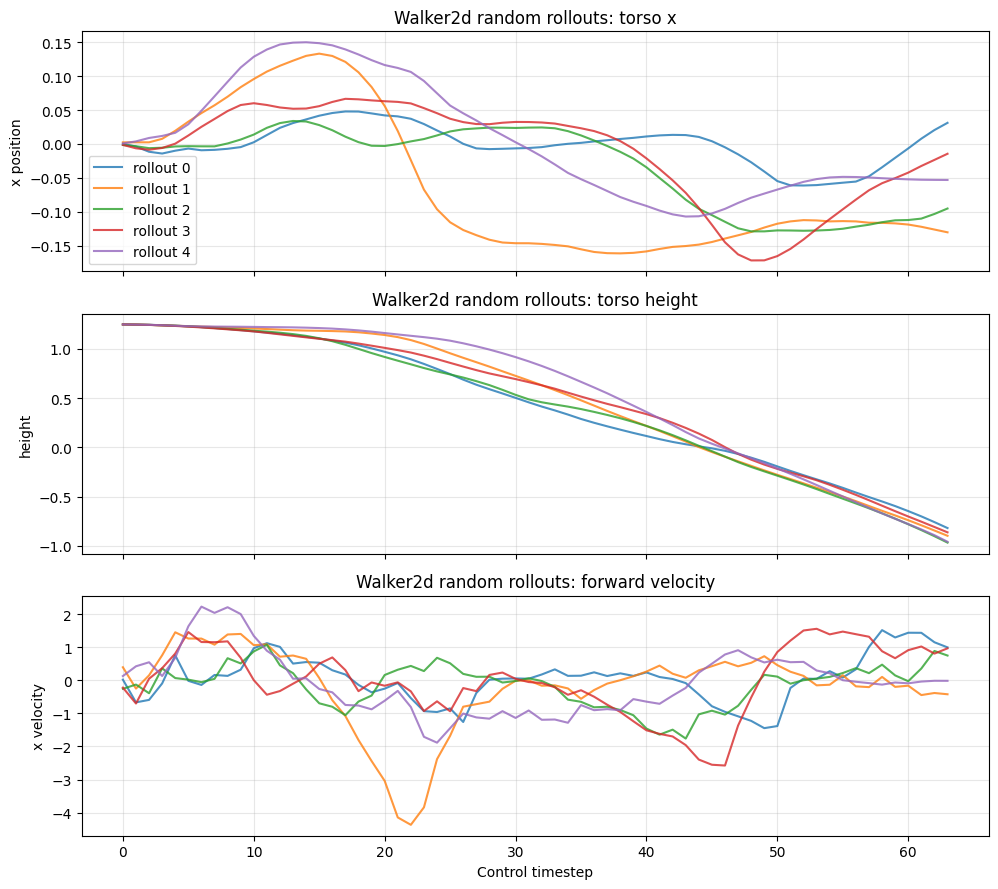

In [ ]:
# Convert the first 5 rollouts to NumPy for plotting
walker_states_np = np.asarray(walker_states[:5])
qpos_start = 0
qvel_start = walker_model.nq

# Plot torso x-position, torso height, and forward velocity for sample rollouts
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for i in range(walker_states_np.shape[0]):
    axes[0].plot(walker_states_np[i, :, qpos_start + 0], alpha=0.8, label=f"rollout {i}")
    axes[1].plot(walker_states_np[i, :, qpos_start + 1], alpha=0.8)
    axes[2].plot(walker_states_np[i, :, qvel_start + 0], alpha=0.8)

# Horizontal motion
axes[0].set_title("Walker2d random rollouts: torso x")
axes[0].set_ylabel("x position")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Body remains upright or falls
axes[1].set_title("Walker2d random rollouts: torso height")
axes[1].set_ylabel("height")
axes[1].grid(True, alpha=0.3)

# Forward velocity signal used in locomotion rewards
axes[2].set_title("Walker2d random rollouts: forward velocity")
axes[2].set_xlabel("Control timestep")
axes[2].set_ylabel("x velocity")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()